In [ ]:
from SystematicScanOfConvergence.MakeHam import *
# from Permutations.Helpers import *
from Permutations.Helpers import *
import matplotlib.pyplot as plt
from math import factorial
from scipy.sparse.linalg import eigsh
from Permutations.SKQD import *
from Permutations.PowerSampling import *
from Permutations.CSRtoSPO import *
from BARK import *
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import tqdm
from scipy.sparse import csr_matrix
from qiskit.quantum_info import Operator
from qiskit.quantum_info import SparsePauliOp
from new_approach.Hamiltonian_controlled_sparsity import make_controlled_sparse_ground_state_hamiltonian_from_qubits, make_controlled_sparse_ground_state_hamiltonian_fast
from new_approach.krab_4 import *

In [ ]:
H, H_spo, psi, support, info = (
    make_controlled_sparse_ground_state_hamiltonian_fast(
        n_qubits=8,
        ground_state_sparsity=0.1,
        hamiltonian_sparsity=0.5,
        seed=123,
        ground_energy=-5,
        gap=1.0,
        return_info=True,
    )
)

In [7]:
correct_energy, correct_state = eigsh(H, k=1, which='SA')
# Sparsity of the correct ground state
amps = np.abs(correct_state[:, 0]) ** 2
initial = np.argmax(amps)

initial_bark = format(initial, '0' + str(int(np.log2(H.shape[0]))) + 'b')

In [ ]:
# ============================================================
# Example usage
# ============================================================

# Q can be anything from a list (1st item applied in 1st Ham application, 2nd in 2nd, 6th in 6th and all following), to a function to an int.

result = selected_krylov_ground_state(
    H=H,
    initial_bitstring=initial_bark,
    # Q=[600, 600, 600, 600, 100, 50],
    # Q=lambda app: max(50, int(600 * 0.95**app)),
    Q=500,
    delta=1e-8,
    epsilon=1e-6,
    n_iterations=30,
    max_subspace_dim=np.inf,
    score_mode="residual",
)

print("Final energy:", result.final_energy)
print("Final subspace size:", len(result.final_bitstrings))


Final energy: -5.000000000000012
Final subspace size: 411


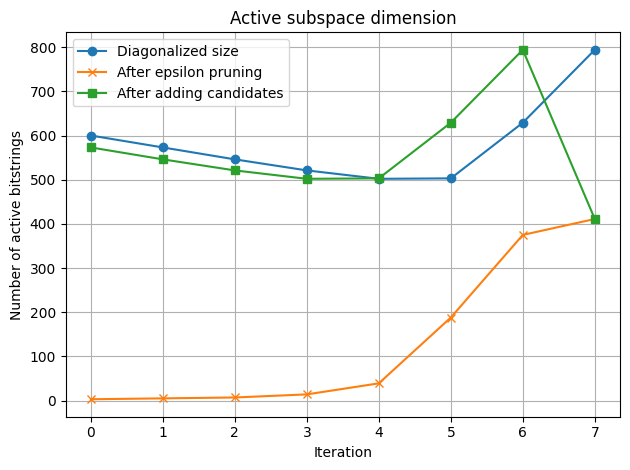

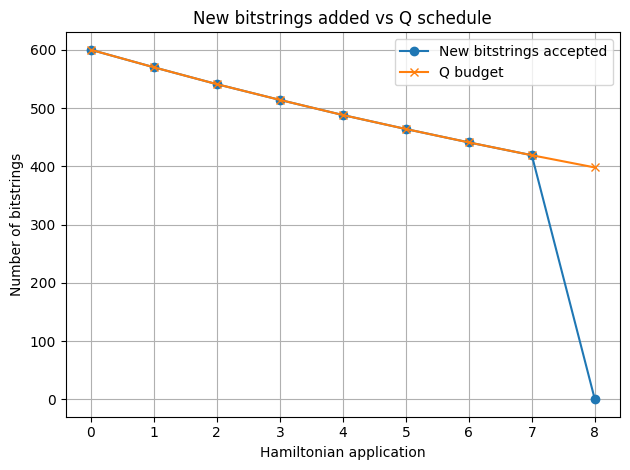

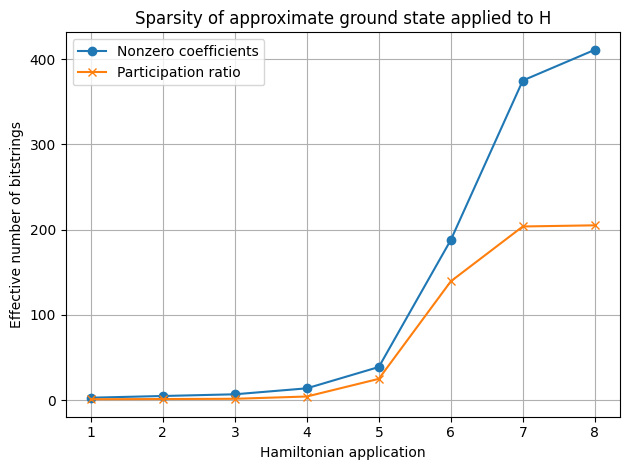

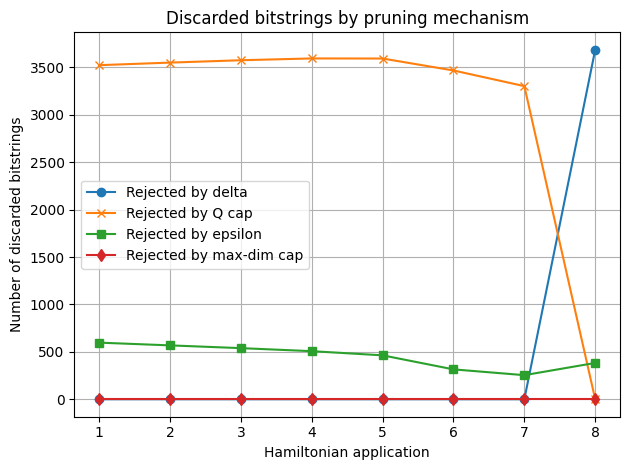

In [24]:
fig1, fig2, fig3, fig4 = plot_selected_krylov_diagnostics(result)
plt.show()